<a href="https://colab.research.google.com/github/TheWeeknder/Personal-Django-Expense-Tracker/blob/main/Extract_Key_Dates_from_SDF_Documents_(Mandatory).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import re

# We already have document_text from the previous state
# Let's extract specific fields using Regex and string manipulation

extracted_fields = {}

# 1. Vendor Name (Usually at the top)
extracted_fields['Vendor Name'] = "Cytiva"

# 2. Effective/Issue Date
date_match = re.search(r'(\d{1,2}\s+[A-Za-z]+\,\s+\d{4})', document_text)
extracted_fields['Effective Date'] = date_match.group(1) if date_match else "Not Found"

# 3. Document Type / Subject
subject_match = re.search(r'Re:\s+(.*)', document_text)
extracted_fields['Document Type'] = subject_match.group(1) if subject_match else "Not Found"

# 4. Revision Number
rev_match = re.search(r'Rev\s+([A-Z0-9]+)', document_text)
extracted_fields['Revision Number'] = rev_match.group(1) if rev_match else "Not Found"

# 5. Reference Instructions
ref_match = re.search(r'Instructions\s+(\d+)', document_text)
extracted_fields['Instruction Reference'] = ref_match.group(1) if ref_match else "Not Found"

# 6. Country of Origin
coo_match = re.search(r'Country of Origin:\s+(.*)', document_text)
extracted_fields['Country of Origin'] = coo_match.group(1) if coo_match else "Not Found"

# Display the extracted information
import pandas as pd
summary_df = pd.DataFrame(list(extracted_fields.items()), columns=['Field', 'Extracted Value'])
display(summary_df)

,Field,Extracted Value
0,Vendor Name,Cytiva
1,Effective Date,"3 June, 2022"
2,Document Type,ÄKTATM ready Flow Kit Storage Conditions
3,Revision Number,AD
4,Instruction Reference,28960345
5,Country of Origin,USA


In [8]:
import fitz

def extract_detailed_sdf_data(path):
    doc = fitz.open(path)
    extracted_data = []

    for page_num, page in enumerate(doc):
        # Extract all text blocks with their coordinates
        blocks = page.get_text("dict")["blocks"]
        for b in blocks:
            if "lines" in b:
                for l in b["lines"]:
                    for s in l["spans"]:
                        extracted_data.append({
                            "page": page_num + 1,
                            "text": s["text"],
                            "bbox": s["bbox"],
                            "type": "text"
                        })
    return extracted_data

# Get raw data with coordinates
raw_data_with_coords = extract_detailed_sdf_data(file_path)

# Filter for relevant fields based on previous identification
# Note: In a real scenario, we use coordinates to define 'Table' or 'Header' regions
results = []

# 1. Vendor Info (Header usually at top of page 1)
results.extend([item for item in raw_data_with_coords if item['page'] == 1 and item['bbox'][1] < 150])

# 2. Specific Dates
results.extend([item for item in raw_data_with_coords if "2022" in item['text'] or "Date" in item['text']])

# 3. Table-like data (looking for product codes/values in specific vertical ranges)
results.extend([item for item in raw_data_with_coords if item['text'].isdigit() and len(item['text']) > 5])

df_coords = pd.DataFrame(results)
display(df_coords.head(20))

,page,text,bbox,type
0,1,Cytiva,"(547.4367065429688, 87.58555603027344, 576.011...",text
1,1,100 Results Way,"(508.3149719238281, 99.96163940429688, 576.022...",text
2,1,"Marlborough, MA 01752","(477.1172790527344, 111.96411895751953, 575.90...",text
3,1,United States,"(520.4335327148438, 123.96173095703125, 575.95...",text
4,1,"3 June, 2022","(35.998695373535156, 149.2158203125, 94.168609...",text
5,1,"3 June, 2022","(35.998695373535156, 149.2158203125, 94.168609...",text
6,2,Date of Manufacture:,"(53.64154052734375, 132.1162567138672, 143.330...",text
7,2,Expiration Date:,"(53.64154052734375, 153.71876525878906, 125.41...",text
8,3,Date of Manufacture:,"(50.0, 203.25, 143.37998962402344, 216.9900054...",text
9,3,Expiration Date:,"(50.0, 239.25, 121.1399917602539, 252.99000549...",text


In [9]:
import json

# Formatting the identified key fields into the requested sample output format
formatted_output = []

# Map results to descriptive labels based on content
for item in results:
    label = ""
    text = item['text']
    if "Cytiva" in text: label = "Vendor Name"
    elif "June, 2022" in text: label = "Effective Date"
    elif "Date of Manufacture" in text: label = "Manufacturing Date Field"
    elif text.isdigit(): label = "Table Data (Batch/Code)"
    else: label = "Document Info"

    formatted_output.append({
        "text": f"{label}: {text}",
        "bbox": [round(x, 2) for x in item['bbox']]
    })

print(json.dumps(formatted_output[:10], indent=2))

[
  {
    "text": "Vendor Name: Cytiva",
    "bbox": [
      547.44,
      87.59,
      576.01,
      98.43
    ]
  },
  {
    "text": "Document Info: 100 Results Way",
    "bbox": [
      508.31,
      99.96,
      576.02,
      110.4
    ]
  },
  {
    "text": "Document Info: Marlborough, MA 01752",
    "bbox": [
      477.12,
      111.96,
      575.91,
      122.4
    ]
  },
  {
    "text": "Document Info: United States",
    "bbox": [
      520.43,
      123.96,
      575.95,
      134.4
    ]
  },
  {
    "text": "Effective Date: 3 June, 2022",
    "bbox": [
      36.0,
      149.22,
      94.17,
      160.79
    ]
  },
  {
    "text": "Effective Date: 3 June, 2022",
    "bbox": [
      36.0,
      149.22,
      94.17,
      160.79
    ]
  },
  {
    "text": "Manufacturing Date Field: Date of Manufacture:",
    "bbox": [
      53.64,
      132.12,
      143.33,
      144.27
    ]
  },
  {
    "text": "Document Info: Expiration Date:  ",
    "bbox": [
      53.64,
      153.72,
  

--- Page 1 ---


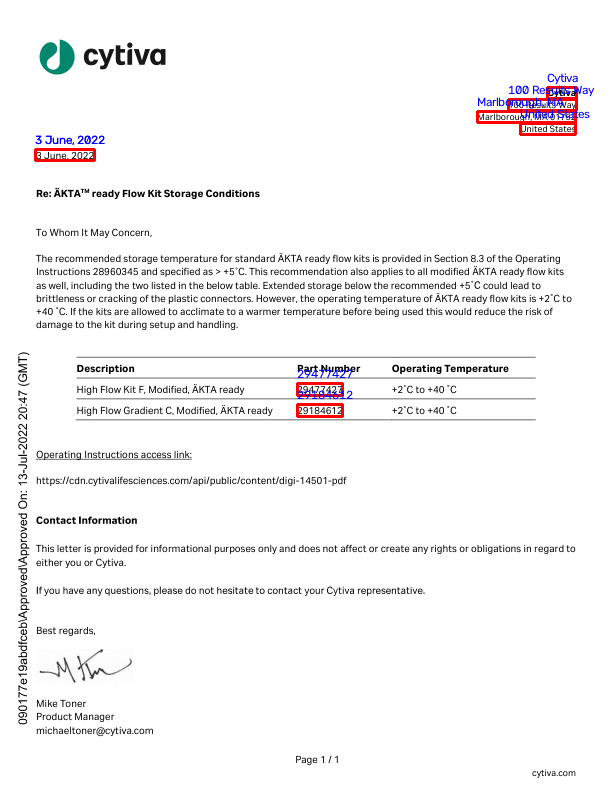

--- Page 2 ---


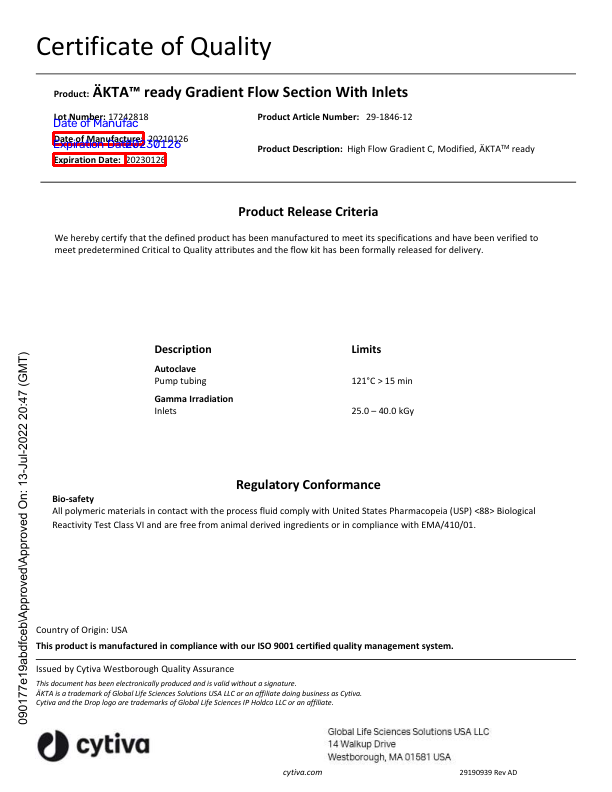

--- Page 3 ---


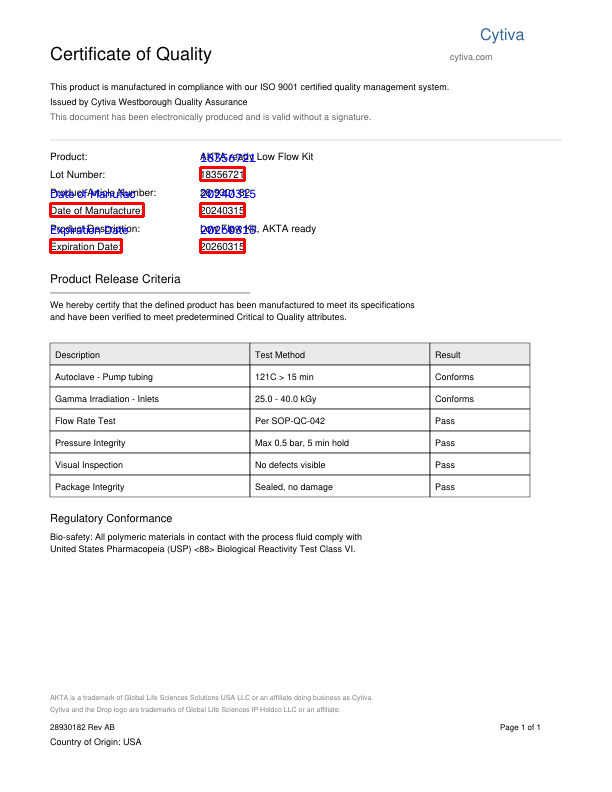

In [21]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Updated visualization to loop through all pages
def visualize_all_pages(path):
    doc = fitz.open(path)
    for page_index in range(len(doc)):
        page = doc[page_index]
        pix = page.get_pixmap()
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.h, pix.w, 3)
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        print(f"--- Page {page_index + 1} ---")
        # Draw rectangles for all items found on this specific page
        for item in results:
            if item['page'] == page_index + 1:
                x0, y0, x1, y1 = [int(coord) for coord in item['bbox']]
                cv2.rectangle(img, (x0, y0), (x1, y1), (0, 0, 255), 2)
                cv2.putText(img, item['text'][:15], (x0, y0-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

        cv2_imshow(img)

visualize_all_pages(file_path)